In [16]:
from sklearn.cluster import KMeans
import scipy.sparse
import pickle
import numpy as np

In [9]:
# Carregar o modelo TF-IDF e a matriz
with open('out\dblp-v10-tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

In [10]:
X = scipy.sparse.load_npz('out\dblp-v10-tfidf_matrix.npz')

In [11]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=5, random_state=42)

In [12]:
# Obter os rótulos
labels = kmeans.labels_
print("Rótulos dos clusters:", labels)

Rótulos dos clusters: [1 2 2 ... 4 0 2]


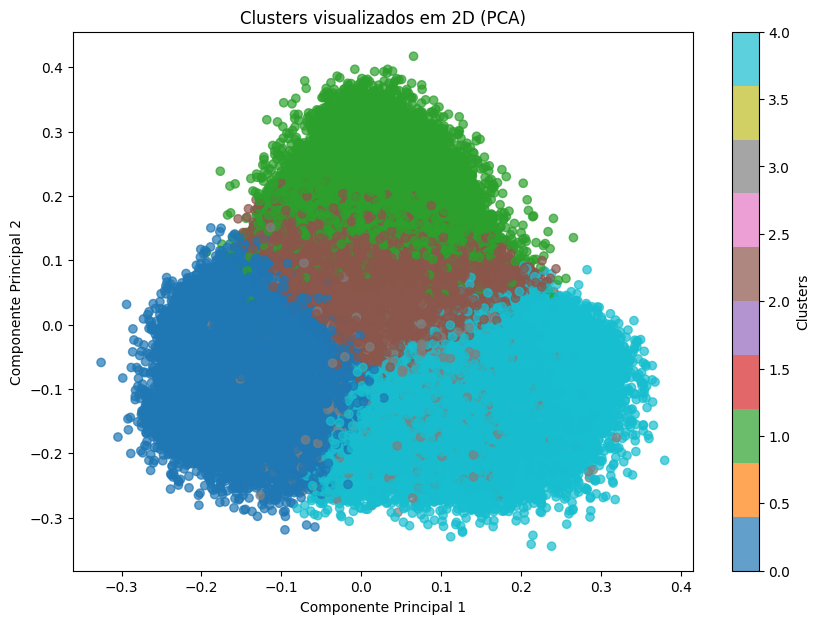

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Converter para matriz densa, se necessário
X_dense = X.toarray()

# Redução de dimensionalidade para 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# Plotar os clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label="Clusters")
plt.title("Clusters visualizados em 2D (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()


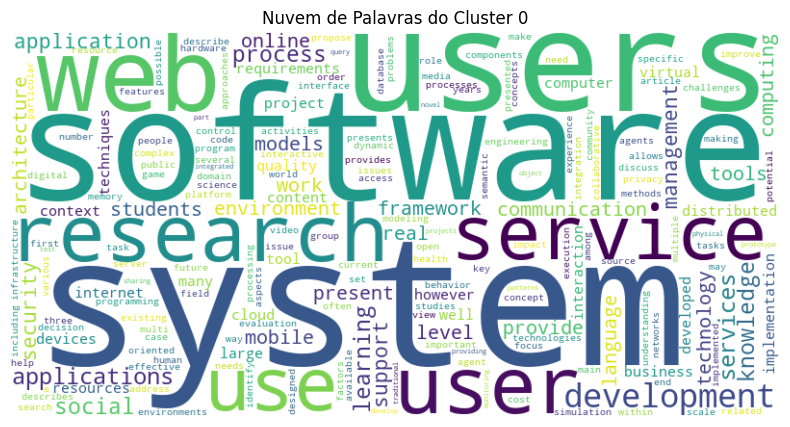

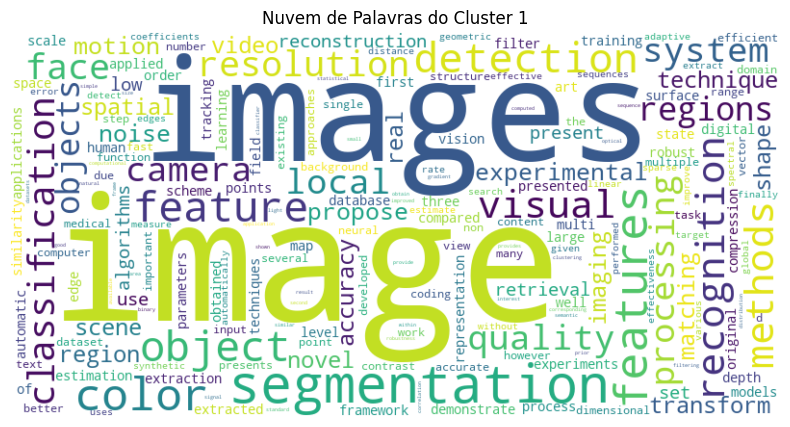

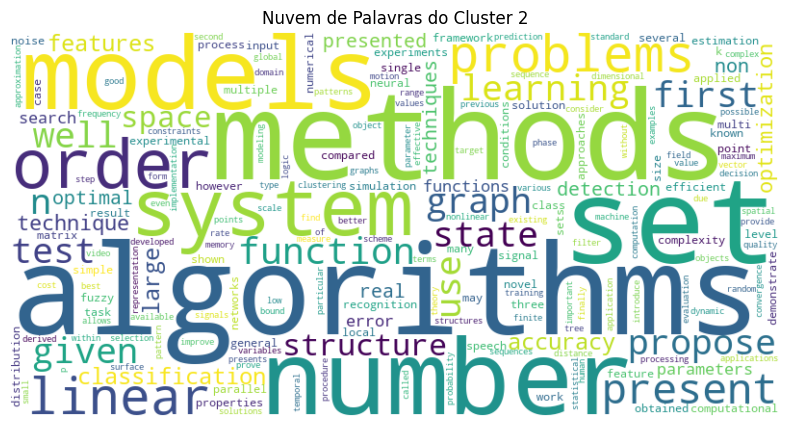

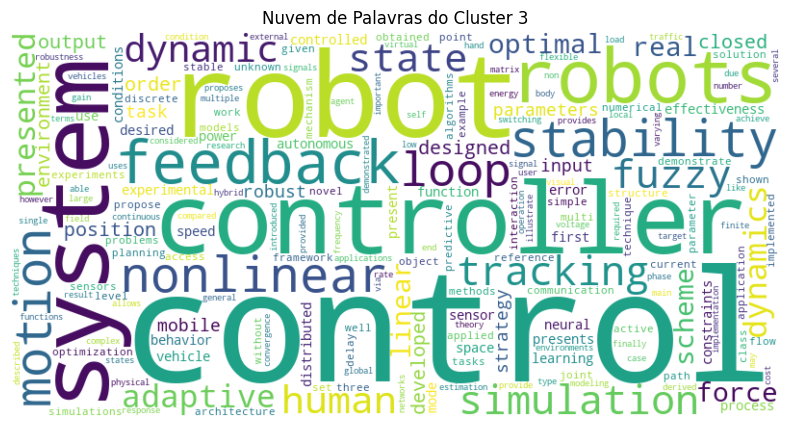

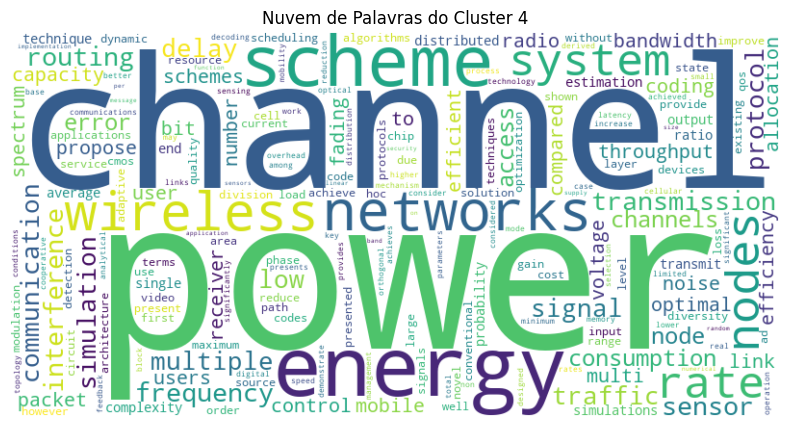

In [17]:
from wordcloud import WordCloud

# Obter as palavras do vocabulário
vocabulario = vectorizer.get_feature_names_out()

# Gerar nuvens de palavras para cada cluster
for cluster_id in np.unique(labels):
    # Filtrar os documentos do cluster
    cluster_docs = X_dense[labels == cluster_id]
    
    # Somar as frequências TF-IDF de todas as palavras no cluster
    cluster_tfidf_sum = cluster_docs.sum(axis=0)
    
    # Criar um dicionário de palavras e suas pontuações
    palavras_tfidf = {vocabulario[i]: cluster_tfidf_sum[i] for i in range(len(vocabulario))}
    
    # Gerar a nuvem de palavras
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(palavras_tfidf)
    
    # Exibir a nuvem de palavras
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Nuvem de Palavras do Cluster {cluster_id}")
    plt.axis('off')
    plt.show()
